# Build Initial Single Factor GAM Model
## Setup Jupyter Notebook
### Import packages

In [1]:
# Import external packages
import pandas as pd
import os
import numpy as np
import random 
import pyarrow.parquet as pq
import sys
import shutil
import pickle
import warnings
from itertools import chain

from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_percentage_error

from pygam import GAM, s, te, f, l

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import LogLocator

import optuna
from optuna.visualization import matplotlib as optunampl

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 260)
warnings.filterwarnings("ignore")

In [2]:
# Import the internal package
package_loc = r"../"

# Add the package location to system paths
sys.path.append(package_loc)

from src import utils
from src.gam import training, explain

### Define Paths

In [ ]:
###################################################
###################################################

data_version = "v2"
model_version = "v3"

###################################################
###################################################

# Define the directories for input and output
dir_input = f"input"
dir_data = f"export"
dir_output = f"output"

model_data_file = f"{dir_data}/gam_modelling_data_{data_version}.parquet"

# Define the name of the rating tables that defines the GAM model 
sf_rating_table_output = f"{dir_output}/single_factor_rating_tables_{model_version}.pkl"

print(os.listdir(dir_input))
print(os.listdir(dir_data))
print(os.listdir(dir_output))

['.gitkeep', 'CMI TA DB 2016 Datasheet v02 2024-06-17.xlsb', 'CMI TA DB 2017 Datasheet v02 2024-06-17.xlsb', 'CMI TA DB 2018 Datasheet v01 2022-05-20.xlsb', 'CMI TA DB 2019 Datasheet v01 2022-05-20.xlsb', 'CMI TA DB 2020 Datasheet v01 2022-05-20.xlsb']
['CMI Categorical Bands (with CalendarYear).xlsx', 'gam_modelling_data_v2.parquet']
['02_model_note_v3.xlsx', '03_model_note_v3.xlsx', 'gam_initial_v3.pkl', 'single_factor_rating_tables_v3.pkl', 'training_data_folds_v3.pkl']


### Set Variables

In [ ]:
title_fontsize = 25 
label_fontsize = 20 
ticker_fontsize = 15

## Create Modelling Data

In [5]:
model_data = pd.read_parquet(f"{model_data_file}")
model_data

,ProductCategory,Gender,SmokerStatus,DistributionChannel,CommencementYear,JointLifeStatus,SumAssuredBand,Age,Duration,LivesExposure,AmountsExposure,IncurredClaims,AmountIncurred,ExpectedClaims,ExpectedAmountClaims,ComparatorTable,CalendarYear,holdout,random_fold,ProductCategory_cat_level,Gender_cat_level,SmokerStatus_cat_level,DistributionChannel_cat_level,JointLifeStatus_cat_level,CalendarYear_cat_level
unique_id,,,,,,,,,,,,,,,,,,,,,,,,,
0,Other,F,N,B,2001,J,4,49,10,0.986339,10791.699454,0.0,0.0,0.000838,9.172945,TFNL16,CY2016,0,3,2,0,0,0,0,0
1,Other,F,N,B,2003,J,4,43,10,0.415301,35692.456284,0.0,0.0,0.000206,17.667766,TFNL16,CY2016,0,1,2,0,0,0,0,0
2,Other,F,N,B,2003,J,4,44,10,0.584699,48133.442623,0.0,0.0,0.000317,26.088326,TFNL16,CY2016,0,4,2,0,0,0,0,0
3,Other,F,N,B,2003,S,4,51,10,0.581967,5756.663934,0.0,0.0,0.000589,5.825744,TFNL16,CY2016,0,2,2,0,0,0,1,0
4,Other,F,N,B,2003,S,5,38,10,0.461749,63719.904372,0.0,0.0,0.000148,20.390369,TFNL16,CY2016,0,1,2,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2535444,Level,M,S,U,2020,S,3,58,0,0.574863,53414.207650,0.0,0.0,0.001635,151.963421,TMSL16,CY2020,0,5,1,1,1,5,1,4
2535445,Level,M,S,U,2020,S,3,61,0,0.422951,42295.081967,0.0,0.0,0.001723,172.267869,TMSL16,CY2020,0,4,1,1,1,5,1,4
2535446,Level,M,S,U,2020,S,3,62,0,0.122951,13155.737705,0.0,0.0,0.000565,60.424303,TMSL16,CY2020,0,1,1,1,1,5,1,4


In [6]:
###########################################################################
###########################################################################

claim_count = "IncurredClaims"
claim_freq = "AnnualFreq"
weight = "LivesExposure"

# Define the list of numerical features
num_feat = [
    # "CommencementYear", # High correlation with Duration
    "SumAssuredBand",
    "Age",
    "Duration",
]

# Define the list of categorical features
cat_feat = [
    "ProductCategory_cat_level",
    "Gender_cat_level",
    "SmokerStatus_cat_level",
    "DistributionChannel_cat_level",
    "JointLifeStatus_cat_level",
    "CalendarYear_cat_level"
]

###########################################################################
###########################################################################

# Define the target for GAM
model_data[claim_freq] = model_data[claim_count] / model_data[weight]

# Define the full feature list
all_feat = num_feat + cat_feat
print(all_feat)

['SumAssuredBand', 'Age', 'Duration', 'ProductCategory_cat_level', 'Gender_cat_level', 'SmokerStatus_cat_level', 'DistributionChannel_cat_level', 'JointLifeStatus_cat_level', 'CalendarYear_cat_level']


In [7]:
# Check the number of rows with null target
print(model_data[model_data[claim_freq].isnull()].shape[0])

1192


In [8]:
# Null values in the target are caused by zero exposure in the data
model_data[model_data[claim_freq].isnull()].head()

,ProductCategory,Gender,SmokerStatus,DistributionChannel,CommencementYear,JointLifeStatus,SumAssuredBand,Age,Duration,LivesExposure,AmountsExposure,IncurredClaims,AmountIncurred,ExpectedClaims,ExpectedAmountClaims,ComparatorTable,CalendarYear,holdout,random_fold,ProductCategory_cat_level,Gender_cat_level,SmokerStatus_cat_level,DistributionChannel_cat_level,JointLifeStatus_cat_level,CalendarYear_cat_level,AnnualFreq
unique_id,,,,,,,,,,,,,,,,,,,,,,,,,,
2988,Other,F,N,B,2013,S,2,42,1,0.0,0.0,0.0,0.0,0.0,0.0,TFNL16,CY2016,0,2,2,0,0,0,1,0,NaN
7054,Other,F,N,I,2007,S,4,53,7,0.0,0.0,0.0,0.0,0.0,0.0,TFNL16,CY2016,1,6,2,0,0,1,1,0,NaN
8583,Other,F,N,I,2009,S,1,55,5,0.0,0.0,0.0,0.0,0.0,0.0,TFNL16,CY2016,0,5,2,0,0,1,1,0,NaN
9927,Other,F,N,I,2011,J,1,61,4,0.0,0.0,0.0,0.0,0.0,0.0,TFNL16,CY2016,1,6,2,0,0,1,0,0,NaN
24901,Other,F,S,B,2013,S,2,32,1,0.0,0.0,0.0,0.0,0.0,0.0,TFSL16,CY2016,0,1,2,0,1,0,1,0,NaN


In [9]:
# Need to remove rows with 0 exposures
model_data = model_data[
    ~(
        (model_data[claim_freq].isnull())
        | (model_data[claim_freq] == np.inf)
    )
]
model_data

,ProductCategory,Gender,SmokerStatus,DistributionChannel,CommencementYear,JointLifeStatus,SumAssuredBand,Age,Duration,LivesExposure,AmountsExposure,IncurredClaims,AmountIncurred,ExpectedClaims,ExpectedAmountClaims,ComparatorTable,CalendarYear,holdout,random_fold,ProductCategory_cat_level,Gender_cat_level,SmokerStatus_cat_level,DistributionChannel_cat_level,JointLifeStatus_cat_level,CalendarYear_cat_level,AnnualFreq
unique_id,,,,,,,,,,,,,,,,,,,,,,,,,,
0,Other,F,N,B,2001,J,4,49,10,0.986339,10791.699454,0.0,0.0,0.000838,9.172945,TFNL16,CY2016,0,3,2,0,0,0,0,0,0.0
1,Other,F,N,B,2003,J,4,43,10,0.415301,35692.456284,0.0,0.0,0.000206,17.667766,TFNL16,CY2016,0,1,2,0,0,0,0,0,0.0
2,Other,F,N,B,2003,J,4,44,10,0.584699,48133.442623,0.0,0.0,0.000317,26.088326,TFNL16,CY2016,0,4,2,0,0,0,0,0,0.0
3,Other,F,N,B,2003,S,4,51,10,0.581967,5756.663934,0.0,0.0,0.000589,5.825744,TFNL16,CY2016,0,2,2,0,0,0,1,0,0.0
4,Other,F,N,B,2003,S,5,38,10,0.461749,63719.904372,0.0,0.0,0.000148,20.390369,TFNL16,CY2016,0,1,2,0,0,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2535444,Level,M,S,U,2020,S,3,58,0,0.574863,53414.207650,0.0,0.0,0.001635,151.963421,TMSL16,CY2020,0,5,1,1,1,5,1,4,0.0
2535445,Level,M,S,U,2020,S,3,61,0,0.422951,42295.081967,0.0,0.0,0.001723,172.267869,TMSL16,CY2020,0,4,1,1,1,5,1,4,0.0
2535446,Level,M,S,U,2020,S,3,62,0,0.122951,13155.737705,0.0,0.0,0.000565,60.424303,TMSL16,CY2020,0,1,1,1,1,5,1,4,0.0


In [10]:
# Count null values for all columns
model_data.isnull().sum()

ProductCategory                  0
Gender                           0
SmokerStatus                     0
DistributionChannel              0
CommencementYear                 0
JointLifeStatus                  0
SumAssuredBand                   0
Age                              0
Duration                         0
LivesExposure                    0
AmountsExposure                  0
IncurredClaims                   0
AmountIncurred                   0
ExpectedClaims                   0
ExpectedAmountClaims             0
ComparatorTable                  0
CalendarYear                     0
holdout                          0
random_fold                      0
ProductCategory_cat_level        0
Gender_cat_level                 0
SmokerStatus_cat_level           0
DistributionChannel_cat_level    0
JointLifeStatus_cat_level        0
CalendarYear_cat_level           0
AnnualFreq                       0
dtype: int64

### Downsample of 0s in the training data

In [11]:
###########################################################################
###########################################################################

holdout = "holdout"

# Define the sample size of data with no claims 
sample_size = 1500000
random_seed = 653

###########################################################################
###########################################################################

train0 = model_data[(model_data[claim_freq] == 0) & (model_data[holdout] == 0)]
train1 = model_data[(model_data[claim_freq] > 0) & (model_data[holdout] == 0)]

# Generate a list of random numbers without replacement
random.seed(random_seed)
random_numbers = random.sample(
    list(range(len(train0))), len(train0)
)

# Define a random sample that consists of a down-sample of 0 and all the rows with claims
index0 = random_numbers[:sample_size]
train0_rs = train0.iloc[index0]
train_rs = pd.concat([train0_rs, train1], axis=0)
train_rs

,ProductCategory,Gender,SmokerStatus,DistributionChannel,CommencementYear,JointLifeStatus,SumAssuredBand,Age,Duration,LivesExposure,AmountsExposure,IncurredClaims,AmountIncurred,ExpectedClaims,ExpectedAmountClaims,ComparatorTable,CalendarYear,holdout,random_fold,ProductCategory_cat_level,Gender_cat_level,SmokerStatus_cat_level,DistributionChannel_cat_level,JointLifeStatus_cat_level,CalendarYear_cat_level,AnnualFreq
unique_id,,,,,,,,,,,,,,,,,,,,,,,,,,
1974311,Level,M,S,N,2011,S,4,28,8,0.567123,93753.424658,0.0000,0.000000,0.000166,27.376000,TMSL16,CY2019,0,3,1,1,1,3,1,3,0.000000
2363472,Level,F,N,U,2018,J,4,61,2,0.462295,88780.327869,0.0000,0.000000,0.000741,142.226085,TFNL16,CY2020,0,4,1,0,0,5,0,4,0.000000
1315216,Level,F,S,B,2013,S,1,51,4,27.978082,344665.782575,0.0000,0.000000,0.055089,678.646926,TFSL16,CY2018,0,3,1,0,1,0,1,2,0.000000
2340431,Level,F,N,S,2001,J,1,60,10,4.000000,44479.745902,0.0000,0.000000,0.008752,97.321684,TFNL16,CY2020,0,4,1,0,0,4,0,4,0.000000
1546344,Other,M,N,U,2016,S,1,43,2,5.317808,70833.019178,0.0000,0.000000,0.002255,30.033200,TMNL16,CY2019,0,2,2,1,0,5,1,3,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2532466,Level,M,S,U,2015,S,1,61,5,4.780874,65085.249126,1.0526,10526.000000,0.039614,539.296374,TMSL16,CY2020,0,5,1,1,1,5,1,4,0.220169
2532769,Level,M,S,U,2015,S,3,45,4,3.822404,388572.017541,1.0526,105260.000000,0.004969,505.143623,TMSL16,CY2020,0,1,1,1,1,5,1,4,0.275376
2532845,Level,M,S,U,2016,J,1,42,3,1.540984,20586.222978,1.0526,10412.087628,0.001459,19.495153,TMSL16,CY2020,0,2,1,1,1,5,0,4,0.683070


In [12]:
# Calculate the actual frequency in the sample vs the one in the full training data
cf_rs = train_rs[claim_count].sum() / train_rs[weight].sum()

cf = (
    model_data[model_data[holdout] == 0][claim_count].sum()
    / model_data[model_data[holdout] == 0][weight].sum()
)

print(f"Actual Freq in the down-sample: {cf_rs:.4%}")
print(f"Actual Freq in the full training data: {cf:.4%}")

Actual Freq in the down-sample: 0.1696%
Actual Freq in the full training data: 0.1314%


In [13]:
# Calculate the base adjustment required to to applied to the model outputs
base_adj = cf / cf_rs
print(f"Base Adjustment: {base_adj:.4f}")

Base Adjustment: 0.7744


### Define required dataframes

In [14]:
###########################################################################
###########################################################################

holdout = "holdout"
random_fold = "random_fold"
num_fold = 5  # Number of folds in the training data

###########################################################################
###########################################################################

# Define the training and holdout dataframes
X_train_rs = train_rs[all_feat]
y_train_rs = train_rs[claim_freq]
w_train_rs = train_rs[weight]

X_test = model_data.loc[model_data[holdout] == 1, all_feat]
y_test = model_data.loc[model_data[holdout] == 1, claim_freq]
w_test = model_data.loc[model_data[holdout] == 1, weight]

# Define the cross-validation folds required for hyperparameter tuning
random_fold_values = train_rs[random_fold].values

# Define a list of tuples, each first element contains indices for the training fold and each  second element contains indices for the holdout
folds = []
df_ = pd.DataFrame(
    zip(range(len(random_fold_values)), random_fold_values),
    columns=["row_index", random_fold],
)

for i in range(num_fold):
    index_train = df_[df_[random_fold] != i + 1]["row_index"].to_list()
    index_valid = df_[df_[random_fold] == i + 1]["row_index"].to_list()
    folds.append((index_train, index_valid))

valid_folds = [k[1] for k in folds]
check = np.sort(np.array(list(chain(*valid_folds)))) == np.arange(len(X_train_rs))

assert check.sum() == len(
    X_train_rs
), "Not all the rows in the training data are included in the data folds."

In [15]:
# Save down the training data, the data folds and base adjustment for use in the subsequent notebooks
with open(f"{dir_output}/training_data_folds_{model_version}.pkl", "wb") as file:
    pickle.dump((X_train_rs, y_train_rs, w_train_rs, folds, base_adj), file)

In [16]:
# Create a term string for GAM training
term_string, num_feat_map, cat_feat_map, _ = training.create_term_structure(
    num_feat,
    cat_feat,
    X_train_rs,
)
print(term_string)

s(0, lam=lam_num, n_splines=n_splines)+ s(1, lam=lam_num, n_splines=n_splines)+ s(2, lam=lam_num, n_splines=n_splines) + f(3, lam=lam_cat) + f(4, lam=lam_cat) + f(5, lam=lam_cat) + f(6, lam=lam_cat) + f(7, lam=lam_cat) + f(8, lam=lam_cat)


In [17]:
# In any unseen data, any categorical level not in the training set will be mapped to the mode of the training set
for v in cat_feat:
    unique_level = X_train_rs[v].unique()
    condition = X_test[v].isin(unique_level)
    X_test[v] = np.where(condition, X_test[v], X_train_rs[v].mode().iloc[0])
X_test

,SumAssuredBand,Age,Duration,ProductCategory_cat_level,Gender_cat_level,SmokerStatus_cat_level,DistributionChannel_cat_level,JointLifeStatus_cat_level,CalendarYear_cat_level
unique_id,,,,,,,,,
5,5,39,10,2,0,0,0,1,0
6,5,44,10,2,0,0,0,1,0
16,4,51,10,2,0,0,0,0,0
26,5,53,10,2,0,0,0,0,0
38,5,43,10,2,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
2535416,3,29,0,1,1,1,5,1,4
2535420,3,33,0,1,1,1,5,1,4
2535428,3,41,0,1,1,1,5,1,4


In [18]:
# Create training and validation sets for each permutation of the random folds
X_train_cv = {}
X_valid_cv = {}
w_train_cv = {}
w_valid_cv = {}
y_train_cv = {}
y_valid_cv = {}

for i, (train_index, valid_index) in enumerate(folds):
    X_train_cv[i] = X_train_rs.iloc[train_index]
    X_valid_cv[i] = X_train_rs.iloc[valid_index]

    # Any unseen level in the validation fold needs to be replaced by the mode in the training folds
    for v in cat_feat_map.values():
        unique_level = X_train_cv[i][v].unique()
        condition = X_valid_cv[i][v].isin(unique_level)
        X_valid_cv[i][v] = np.where(
            condition, X_valid_cv[i][v], X_train_cv[i][v].mode().iloc[0]
        )

    w_train_cv[i] = w_train_rs.iloc[train_index]
    w_valid_cv[i] = w_train_rs.iloc[valid_index]
    y_train_cv[i] = y_train_rs.iloc[train_index]
    y_valid_cv[i] = y_train_rs.iloc[valid_index]

## Hyperparameter Tuning

In [44]:
# create study
study = optuna.create_study(direction="minimize")

# define objective
objective = training.OptunaGamObjectiveCV(
    term_string,
    5,
    (6, 10), # Need to experiment with the range 
    (1, 1e3, True), 
    (1, 1e3, True),
    X_train_cv, 
    X_valid_cv, 
    y_train_cv, 
    y_valid_cv,
    w_train_cv, 
    w_valid_cv, 
)

[I 2026-04-06 16:50:23,491] A new study created in memory with name: no-name-ace87cc0-04f5-43a5-8376-d00147f80060


In [45]:
###########################################################################
###########################################################################

n_trials = 30

###########################################################################
###########################################################################

# do study
study.optimize(objective, n_trials=n_trials)

[I 2026-04-06 16:57:37,806] Trial 0 finished with value: 193656.2320072826 and parameters: {'n_splines': 10, 'lam_num': 106.0049463857829, 'lam_cat': 141.92357284591898, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 0 with value: 193656.2320072826.
[I 2026-04-06 17:04:18,920] Trial 1 finished with value: 193641.6458291381 and parameters: {'n_splines': 9, 'lam_num': 1.7013546435883264, 'lam_cat': 30.088679237623836, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 1 with value: 193641.6458291381.
[I 2026-04-06 17:11:25,180] Trial 2 finished with value: 193650.8809470971 and parameters: {'n_splines': 10, 'lam_num': 50.62345523742774, 'lam_cat': 147.36234779157434, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}. Best is trial 1 with value: 193641.6458291381.
[I 2026-04-06 17:16:52,480] Trial 3 finished with value: 193664.2835939239 and parameters: {'n_splines': 7, 'lam_num': 23.893563066669262, 'lam_cat'

In [46]:
# Print best trial
best_trial_number = study.best_trial.number
best_trial_value = study.best_trial.value
print(f"Best trial: {best_trial_number} with value {best_trial_value}\n{'*'*80}")

# Print out the best parameters
best_hyperparams = study.best_params
print(best_hyperparams)

Best trial: 1 with value 193641.6458291381
********************************************************************************
{'n_splines': 9, 'lam_num': 1.7013546435883264, 'lam_cat': 30.088679237623836, 'n_splines_inter': 4, 'lam_num_inter': 1.0, 'lam_cat_inter': 1.0}


In [47]:
###########################################################################
###########################################################################

modelling_log = f"{dir_output}/02_model_note_{model_version}.xlsx"

###########################################################################
###########################################################################

with pd.ExcelWriter(f"{modelling_log}", engine="openpyxl", mode="w") as writer:
    study.trials_dataframe().sort_values("value").to_excel(
        writer, sheet_name="Initial_Tune", index=False
    )

<Axes: title={'center': 'Empirical Distribution Function Plot'}, xlabel='Objective Value', ylabel='Cumulative Probability'>

<Figure size 640x480 with 0 Axes>

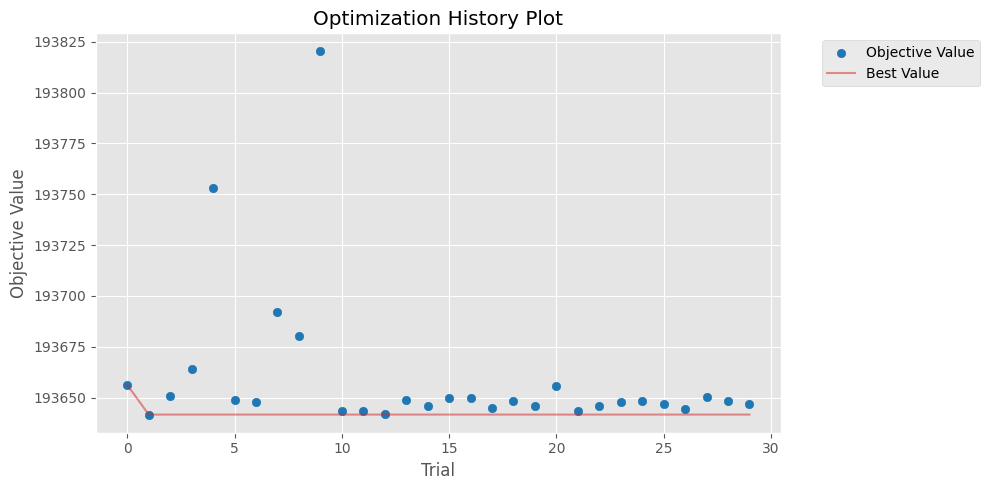

<Figure size 1000x500 with 0 Axes>

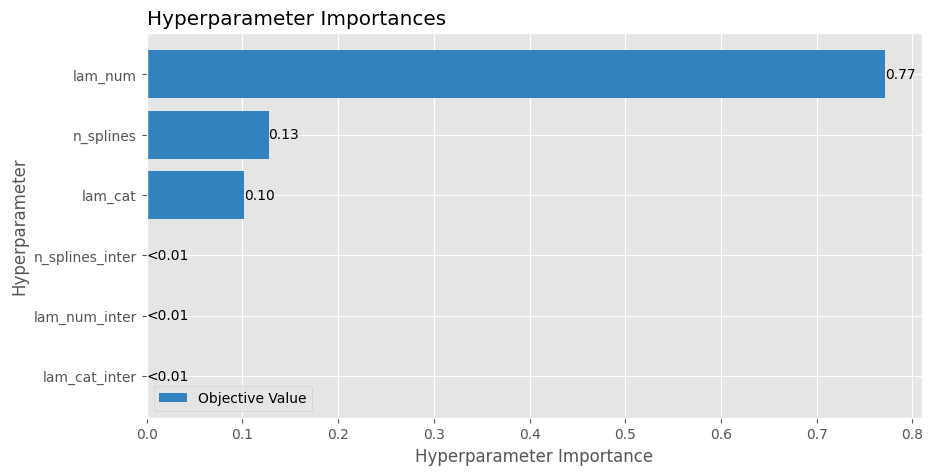

<Figure size 1000x500 with 0 Axes>

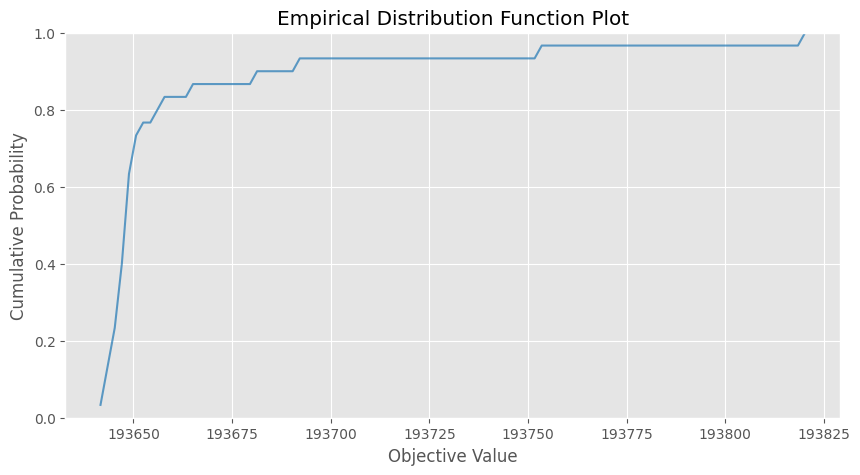

In [48]:
plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_optimization_history(study)

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_param_importances(study) # Plot parameter importance

plt.figure()
plt.rcParams["figure.figsize"] = [10, 5]
optunampl.plot_edf(study) # Plot the empirical cumulative distribution plot

array([<Axes: xlabel='lam_cat', ylabel='Objective Value'>,
       <Axes: xlabel='lam_num'>, <Axes: xlabel='n_splines'>], dtype=object)

<Figure size 1000x500 with 0 Axes>

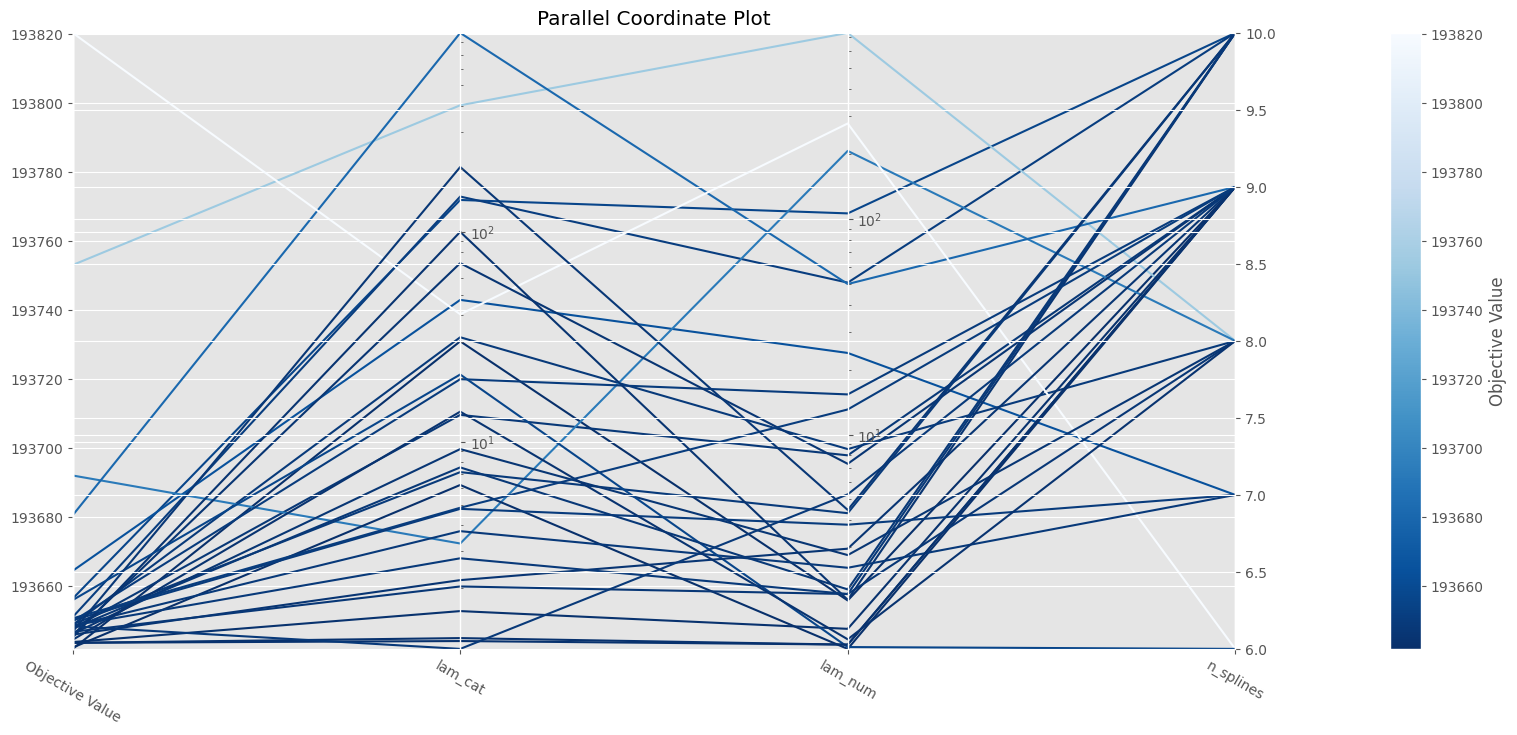

<Figure size 2000x800 with 0 Axes>

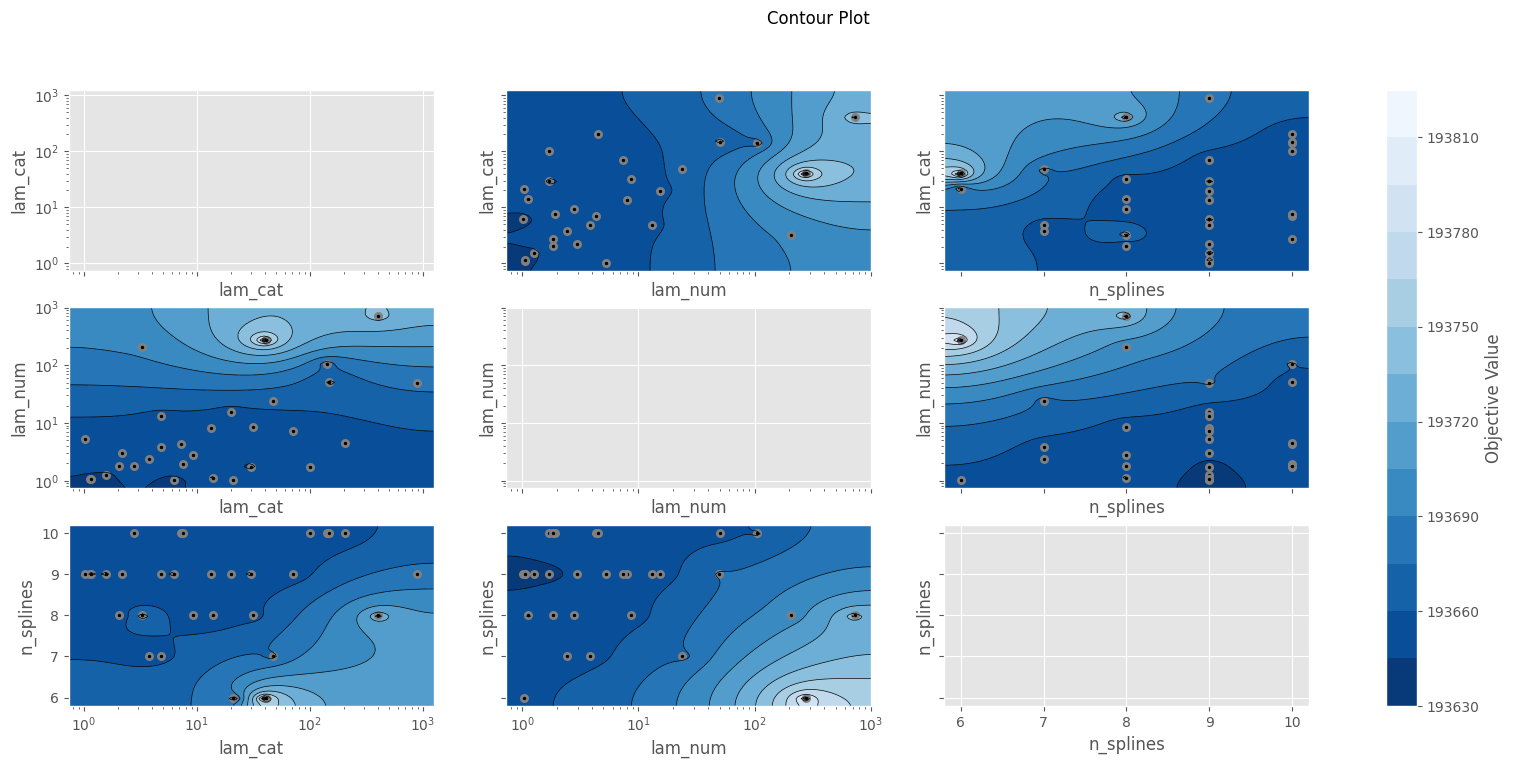

<Figure size 2000x800 with 0 Axes>

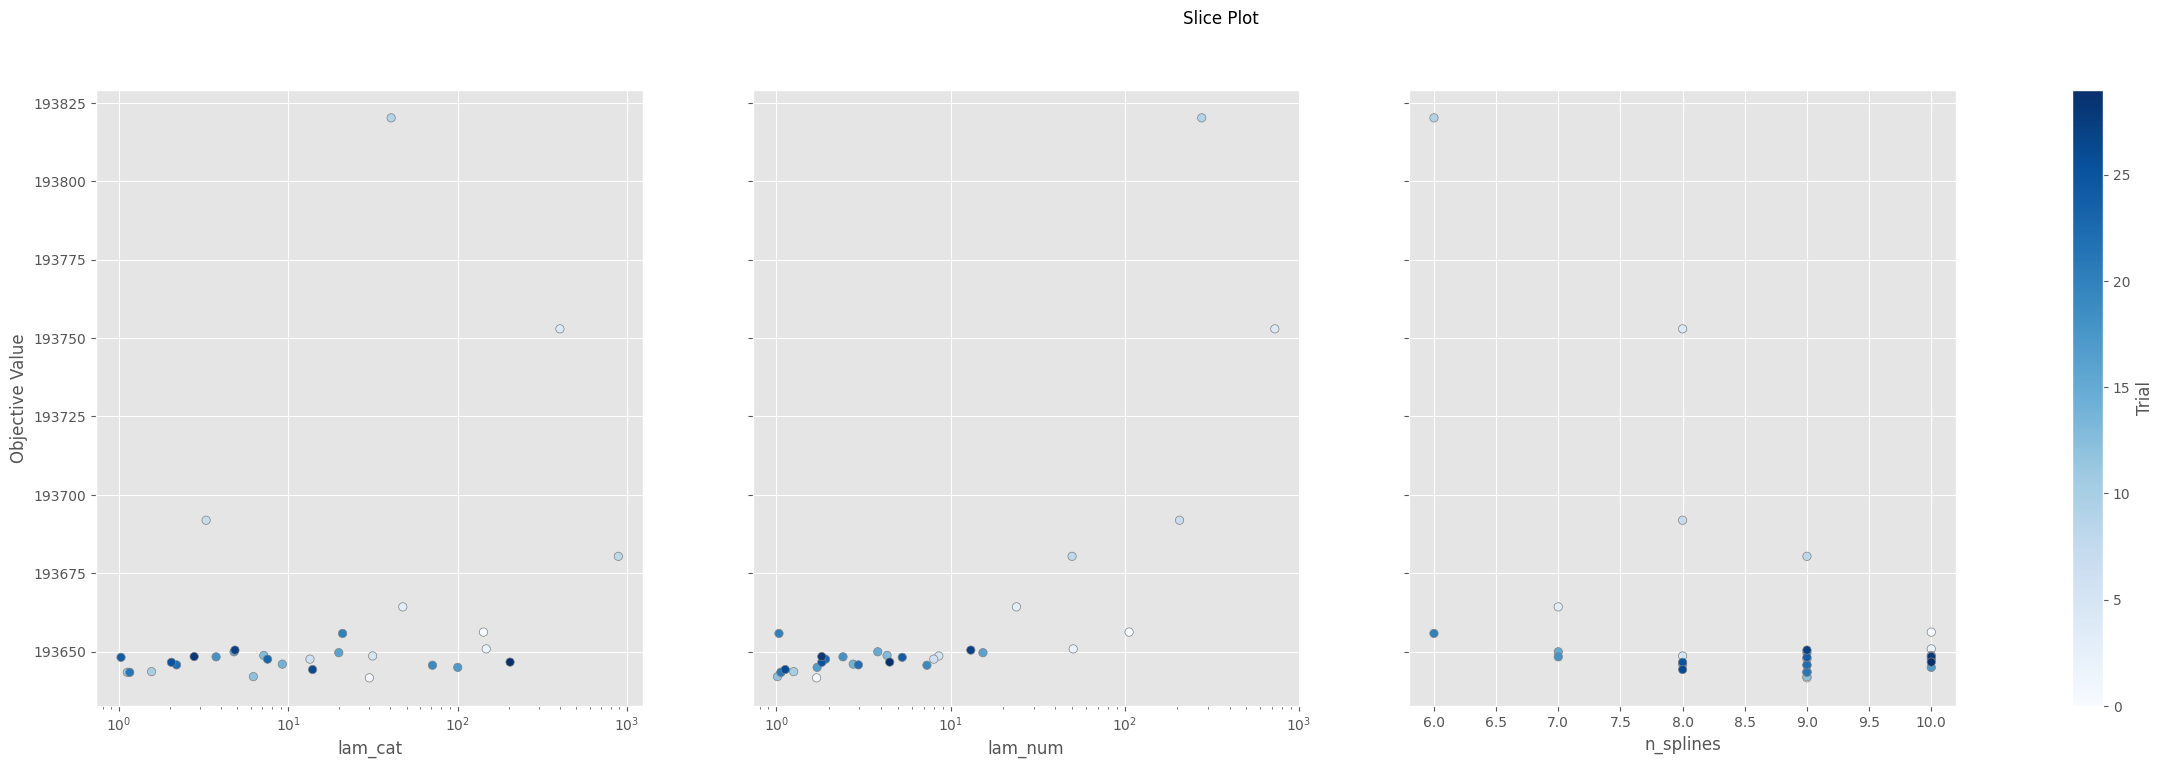

In [49]:
param_importance = optuna.importance.get_param_importances(study)

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_parallel_coordinate(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_contour(study, params=list(param_importance)[:3])

plt.figure()
plt.rcParams["figure.figsize"] = [20, 8]
optunampl.plot_slice(study, params=list(param_importance)[:3])

## Train Single Factor GAM Model

In [19]:
###########################################################################
###########################################################################

modelling_log = f"{dir_output}/02_model_note_{model_version}.xlsx"

###########################################################################
###########################################################################

study_df = pd.read_excel(f"{modelling_log}", "Initial_Tune")
best_params = study_df.sort_values("value").filter(regex="params_").iloc[0].to_dict()
best_params = {k.replace("params_", ""): v for k, v in best_params.items()}

n_splines = int(best_params["n_splines"])
lam_num = best_params["lam_num"]
lam_cat = best_params["lam_cat"]

print(f"n_splines: {n_splines}")
print(f"lam_num: {lam_num}")
print(f"lam_cat: {lam_cat}")

n_splines: 9
lam_num: 1.701354643588326
lam_cat: 30.08867923762384


In [ ]:
# Fit the GAM model
gam_model = GAM(
    eval(term_string),
    distribution="poisson",
    link="log",
).fit(X_train_rs, y_train_rs, weights=w_train_rs)

gam_model.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     32.0539
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                      1535099 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.1262
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6415
Feature Function                  Lam

In [53]:
###########################################################################
###########################################################################

filename = f"{dir_output}/gam_initial_{model_version}.pkl"

###########################################################################
###########################################################################

# Save the GAM model as a pickle file 
with open(filename, 'wb') as file:
    pickle.dump(gam_model, file)

### Derive relativities

In [20]:
###########################################################################
###########################################################################

filename = f"{dir_output}/gam_initial_{model_version}.pkl"

###########################################################################
###########################################################################

# Re-load the GAM model
with open(filename, "rb") as file:
    gam_model = pickle.load(file)

gam_model.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                       PoissonDist Effective DoF:                                     32.0539
Link Function:                          LogLink Log Likelihood:                                       -inf
Number of Samples:                      1535099 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.1262
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6415
Feature Function                  Lam

In [22]:
# Get the intercept of GAM
intercept = np.exp(gam_model.coef_[-1])
print(f"GAM Intercept: {intercept:.2%}")

# Define a list of all variables used in the model
all_feat = list(num_feat_map.values()) + list(cat_feat_map.values())
number_factors = len(all_feat)

GAM Intercept: 1.61%


#### Numerical Variables

In [44]:
# Initilise an empty dictionary for numerical variables
num_rel_dict, intercept_adj_list0 = training.extract_gam_relativity_num(
    gam_model,
    X_train_rs,
    w_train_rs,
    num_feat_map,
    weight,
    intercept_adj_list=[],
)
# Check one set of relativities for a rating factor
num_rel_dict["Duration"]

,Duration,relativity,LivesExposure
0,0,0.492329,2.504579e+06
1,1,0.711655,2.274345e+06
2,2,0.878536,1.956081e+06
3,3,0.974066,1.771911e+06
4,4,1.017484,1.626020e+06
5,5,1.048603,1.447740e+06
6,6,1.100522,1.332483e+06
7,7,1.150477,1.218101e+06
8,8,1.165941,1.111779e+06
9,9,1.142719,1.011155e+06


#### Categorical Variables

In [46]:
###########################################################################
###########################################################################

# Define the directory for the categorical mapping spreadsheet
cat_map_table = f"{dir_data}/CMI Categorical Bands (with CalendarYear).xlsx"

###########################################################################
###########################################################################

cat_rel_dict, intercept_adj_list = training.extract_gam_relativity_cat(
    gam_model,
    X_train_rs,
    w_train_rs,
    cat_feat_map,
    weight,
    cat_map_table, 
    intercept_adj_list=intercept_adj_list0,
)
cat_rel_dict["Gender_cat_level"]

,Gender_cat_level,Gender,relativity,LivesExposure
0,0,F,0.861143,1.093854e+07
1,1,M,1.131828,1.152173e+07


#### Adjust Intercept Term

In [47]:
assert len(intercept_adj_list) == len(
    all_feat
), "# intercept multipliers is not equal to # terms in GAM. Please check!!"

# Perform the adjustment
intercept_final = intercept * np.prod(intercept_adj_list) * base_adj

utils.pretty_print("Intercept Values")
print(f"{'Original':<10}: {intercept:,.5%}")
print(f"{'Adjusted':<10}: {intercept_final:,.5%}")

----------------
Intercept Values
----------------
Original  : 1.61225%
Adjusted  : 0.11990%


#### Export Intercept and Relativities

In [48]:
# Define the output
rating_tables = (intercept_final, num_rel_dict, cat_rel_dict)
# Save
with open(sf_rating_table_output, "wb") as file: 
    pickle.dump(rating_tables, file) 

#### Control Testing

In [49]:
###########################################################################
###########################################################################

new_model_freq = "gam_freq"
cmi_base = "ExpectedClaims"
cmi_freq = "cmi_freq"
new_model_count = "gam_claim_count"

###########################################################################
###########################################################################

# Re-load the rating table outputs
with open(sf_rating_table_output, "rb") as file:
    intercept_final, num_rel_dict, cat_rel_dict = pickle.load(file)

# Define a dataframe that contains predictions, target and weight
ypred_test = gam_model.predict(X_test) * base_adj

ypred_test_df = pd.DataFrame(ypred_test, columns=[new_model_freq], index=X_test.index)
ypred_test_df = (
    ypred_test_df.join(y_test)
    .join(w_test)
    .join(
        model_data[
            [
                claim_count,
                cmi_base,
            ]
        ]
    )
)
ypred_test_df[new_model_count] = ypred_test_df[new_model_freq] * ypred_test_df[weight]
ypred_test_df[cmi_freq] = ypred_test_df[cmi_base] / ypred_test_df[weight]
ypred_test_df

,gam_freq,AnnualFreq,LivesExposure,IncurredClaims,ExpectedClaims,gam_claim_count,cmi_freq
unique_id,,,,,,,
5,0.000316,0.0,0.538251,0.0,0.000187,0.000170,0.000347
6,0.000474,0.0,0.426230,0.0,0.000231,0.000202,0.000542
16,0.000929,0.0,0.002732,0.0,0.000003,0.000003,0.001012
26,0.000997,0.0,0.248634,0.0,0.000299,0.000248,0.001201
38,0.000436,0.0,0.658470,0.0,0.000326,0.000287,0.000495
...,...,...,...,...,...,...,...
2535416,0.000259,0.0,0.814208,0.0,0.000125,0.000211,0.000154
2535420,0.000308,0.0,2.472678,0.0,0.000502,0.000760,0.000203
2535428,0.000539,0.0,2.189071,0.0,0.000919,0.001179,0.000420


In [50]:
###############################################################
###############################################################

# Define the number of decimal places to round the predictions
rounding_num = 7

###############################################################
###############################################################

# Test on the training ata
ypred_train = gam_model.predict(X_train_rs) * base_adj

# Define a procedure to score a dataset using the relativities extracted
X_train_rel = X_train_rs.copy()
rel_list = []

for v, r in num_rel_dict.items():
    X_train_rel[v + "_rel"] = X_train_rel[v].map(r.set_index(v)["relativity"].to_dict())
    rel_list.append(v + "_rel")

for v, r in cat_rel_dict.items():
    X_train_rel[v.replace("_cat_level", "") + "_rel"] = X_train_rel[v].map(
        r.set_index(v)["relativity"].to_dict()
    )
    rel_list.append(v.replace("_cat_level", "") + "_rel")

# Check there are no null values
assert (
    X_train_rel.isnull().sum().sum() == 0
), "There are NA values in relativities calculated. Please check!!"


ypred_train_df = pd.DataFrame(
    ypred_train, columns=[new_model_freq], index=X_train_rs.index
)

ypred_train_df[f"{new_model_freq}_rel"] = (
    X_train_rel[rel_list].prod(axis=1) * intercept_final
)

check_df = ypred_train_df[
    ypred_train_df[new_model_freq].round(rounding_num)
    != ypred_train_df[f"{new_model_freq}_rel"].round(rounding_num)
]

# Check if there is any diff between the predictions from model and the predictions from rating tables
assert (
    len(check_df) == 0
), "There are differences detected between the model predictions and the predictions from rating tables. Please check!!"

### Holdout Assessment

In [51]:
# Poisson Deviance
gam_dev = utils.total_poisson_dev(
    y=ypred_test_df[claim_count],
    y_pred=ypred_test_df[new_model_count],
)
cmi_dev = utils.total_poisson_dev(
    y=ypred_test_df[claim_count],
    y_pred=ypred_test_df[cmi_base],
)

utils.pretty_print("Total Poisson Deviance")
print(f"{'GAM Model':<15}: {gam_dev:,.0f}")
print(f"{'CMI Base':<15}: {cmi_dev:,.0f}")

----------------------
Total Poisson Deviance
----------------------
GAM Model      : 52,915
CMI Base       : 52,946


In [52]:
corr, _ = pearsonr(
    ypred_test_df[cmi_freq], ypred_test_df[new_model_freq]
)
print(f"Correlation between GAM and CMI Base Rate: {corr:.2%}")

Correlation between GAM and CMI Base Rate: 98.36%


In [53]:
################################################################
################################################################

# Define the list of new to current model prediction column names
predict = [new_model_count, cmi_base]

################################################################
################################################################

d = utils.DoubleLift(
    ypred_test_df, predict, claim_count, weight, [0.00, 0.98], approx_num_band=25
)

mape_gam = mean_absolute_percentage_error(
    d.double_lift_table[claim_count],
    d.double_lift_table[predict[0]],
    sample_weight=d.double_lift_table[weight],
)
mape_expected = mean_absolute_percentage_error(
    d.double_lift_table[claim_count],
    d.double_lift_table[predict[1]],
    sample_weight=d.double_lift_table[weight],
)
print(f"{'MAPE - GAM':<30}: {mape_gam:.2%}")
print(f"{'MAPE - CMI Base':<30}: {mape_expected:.2%}")

d.double_lift_table

MAPE - GAM                    : 8.23%
MAPE - CMI Base               : 9.69%


,ratio_band,IncurredClaims,gam_claim_count,ExpectedClaims,LivesExposure
band,,,,,
1,"(0.461, 0.55]",0.000113,0.000155,0.000294,8893.804776
2,"(0.55, 0.6]",0.000252,0.000178,0.000307,24281.211872
3,"(0.6, 0.65]",0.000352,0.000341,0.000541,39140.869945
4,"(0.65, 0.7]",0.000522,0.000647,0.000952,84632.314522
5,"(0.7, 0.75]",0.000920,0.000831,0.001141,206273.301520
6,"(0.75, 0.8]",0.001071,0.000943,0.001214,379766.737166
7,"(0.8, 0.85]",0.001116,0.001015,0.001228,613625.481997
8,"(0.85, 0.9]",0.001142,0.001106,0.001263,829842.429673
9,"(0.9, 0.95]",0.001293,0.001223,0.001321,917013.092469


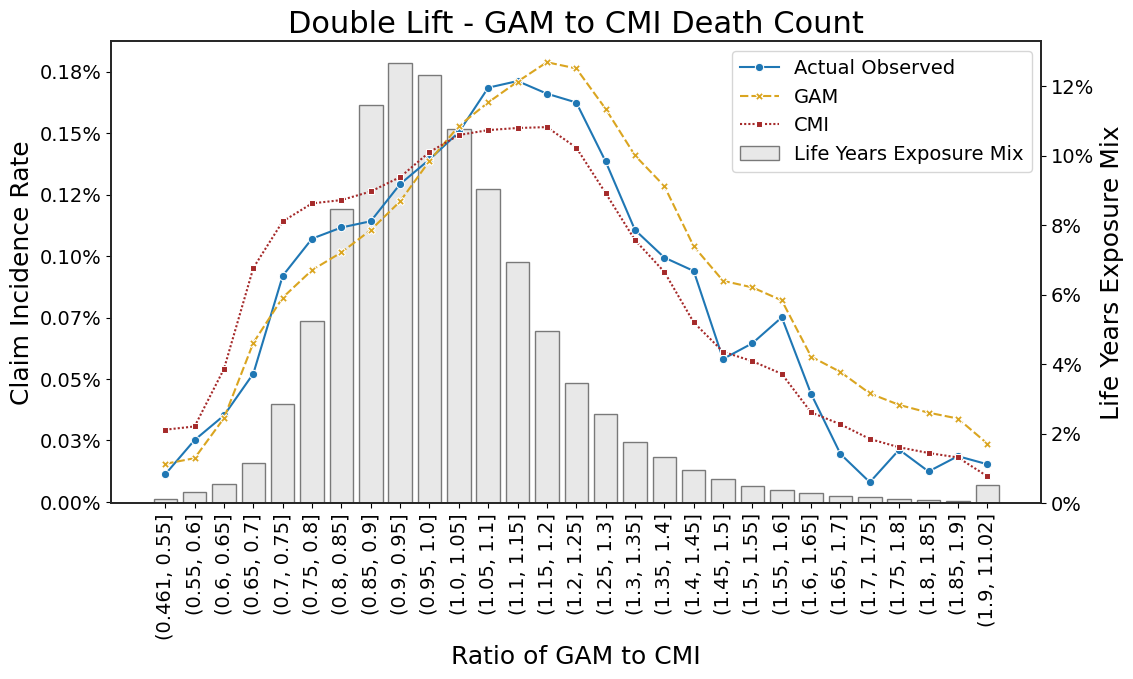

In [54]:
###########################################################################
###########################################################################

param_dict = {
    "title": "Double Lift - GAM to CMI Death Count", 
    "leftylabel": "Claim Incidence Rate", 
    "rightylabel": "Life Years Exposure Mix",
    "target_legend": "Actual Observed", 
    "new_model_legend": "GAM",
    "baseline_legend": "CMI",
    "palette": ["tab:blue", "#DAA520", "#A52A2A"]
}

###########################################################################
###########################################################################

plt.rcParams["axes.edgecolor"] = "0.15"
plt.rcParams["axes.linewidth"] = 1.25

fig, ax = plt.subplots(figsize=(12, 6))

d.plot_double_lift(ax=ax, **param_dict)

## Model Explanation 
### Factor Strength

In [55]:
single_fact_df, _ = explain.factor_strength(
    num_rel_dict, cat_rel_dict, weight=weight
)
single_fact_df

,feature,feature_type,factor_strength
0,Age,numerical,1.401153
1,SmokerStatus,categorical,0.397812
2,Duration,numerical,0.241241
3,Gender,categorical,0.135297
4,SumAssuredBand,numerical,0.096112
5,CalendarYear,categorical,0.028964
6,DistributionChannel,categorical,0.028931
7,JointLifeStatus,categorical,0.026661
8,ProductCategory,categorical,0.015942


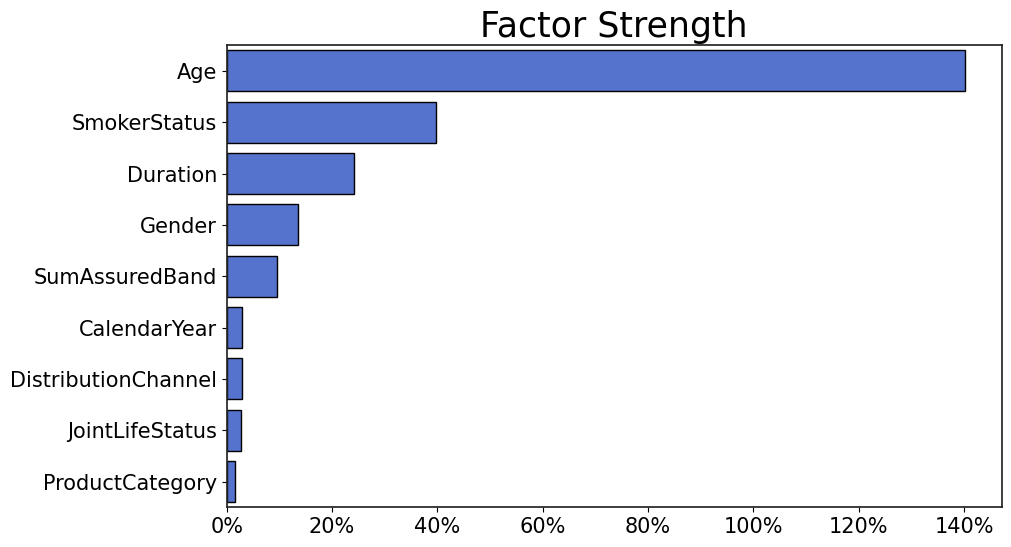

In [56]:
fig, ax = plt.subplots(1, figsize=(10, 6))
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.25

# Plot data
sns.barplot(
    x="factor_strength",
    y="feature",
    data=single_fact_df,
    ax=ax,
    color="royalblue",
    edgecolor="black",
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
ax.tick_params(
    axis="both", which="major", labelsize=ticker_fontsize, labelcolor="black"
)
ax.set_title(f"Factor Strength", fontsize=title_fontsize)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(False)
ax.set_facecolor("white")

In [57]:
# Append the factor strength table to the modelling log
with pd.ExcelWriter(
    f"{modelling_log}", engine="openpyxl", mode="a", if_sheet_exists="replace"
) as writer:
    single_fact_df.to_excel(writer, sheet_name="Sing_Fac_Imp", index=False)

### Single Factor Trend Assessment

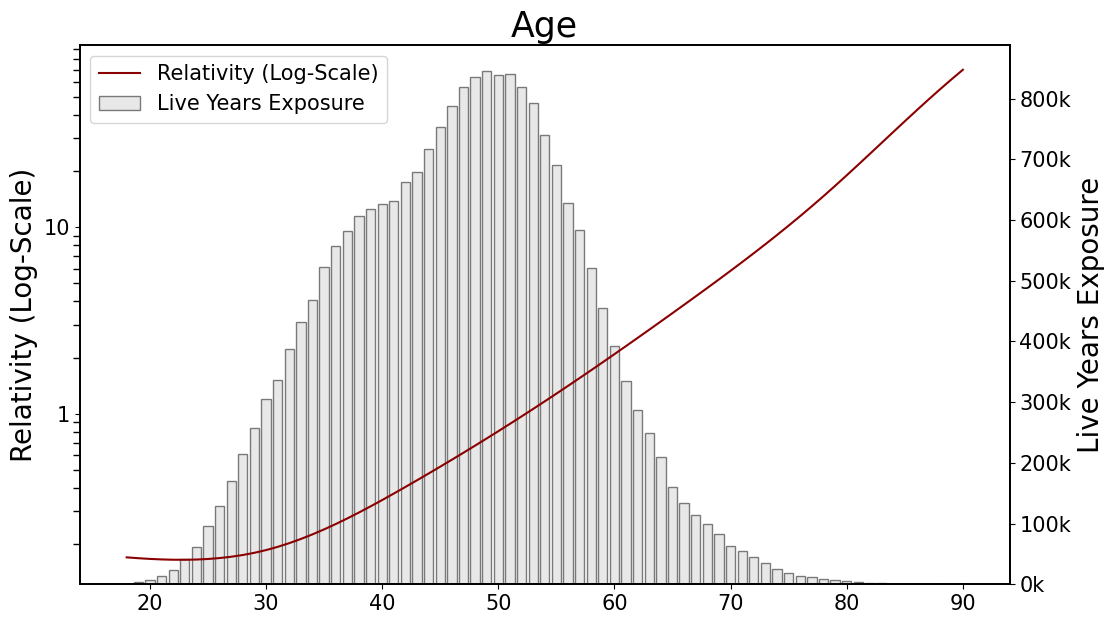

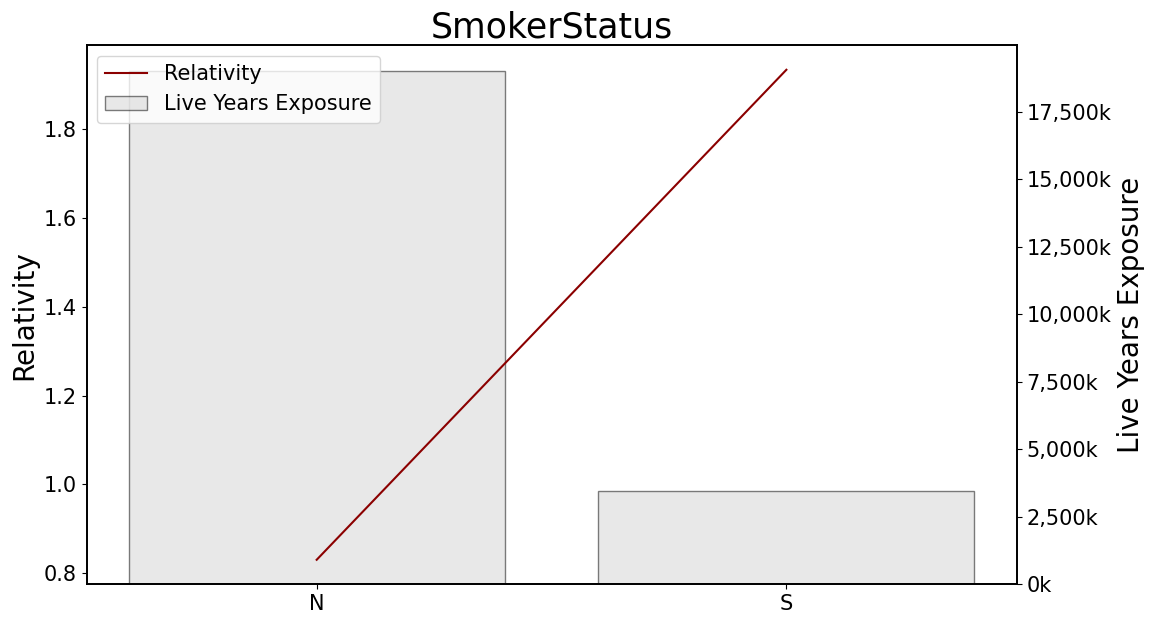

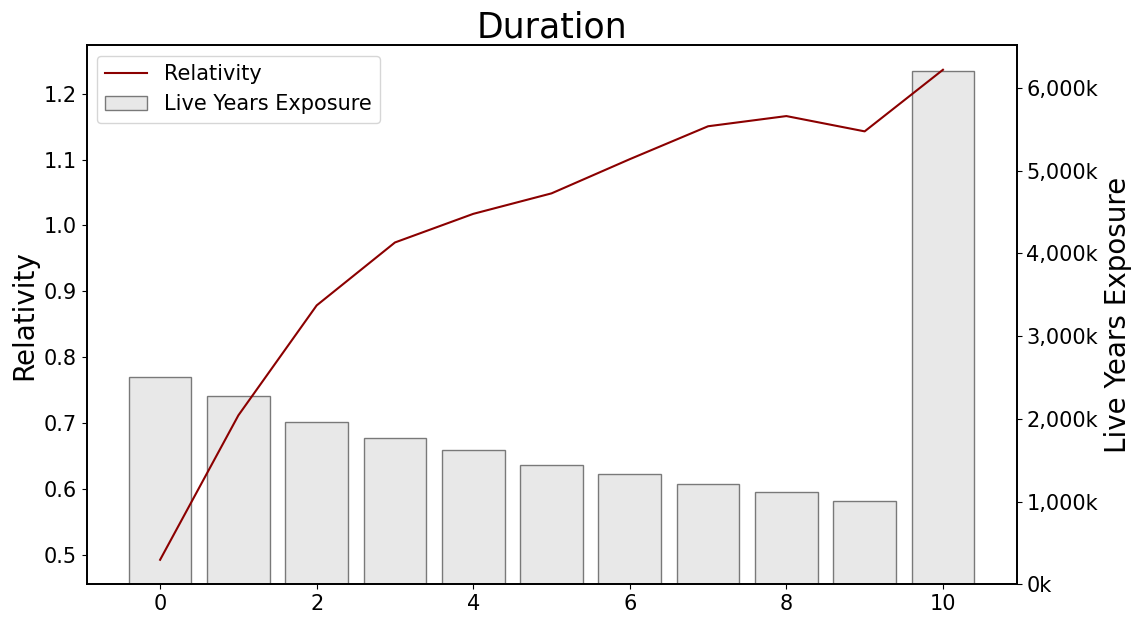

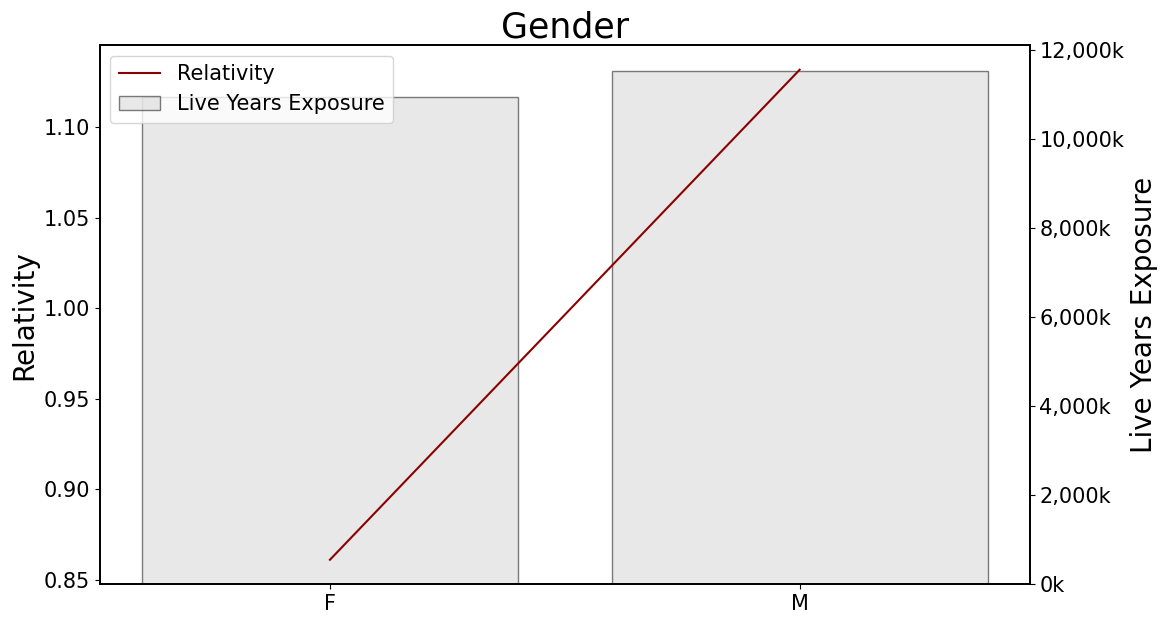

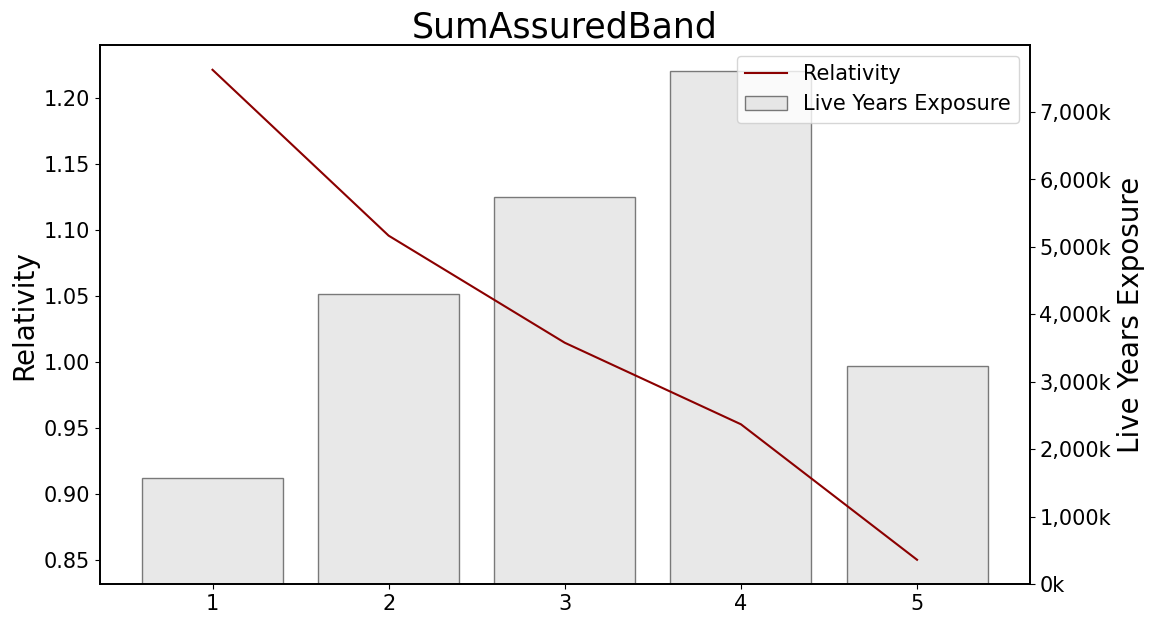

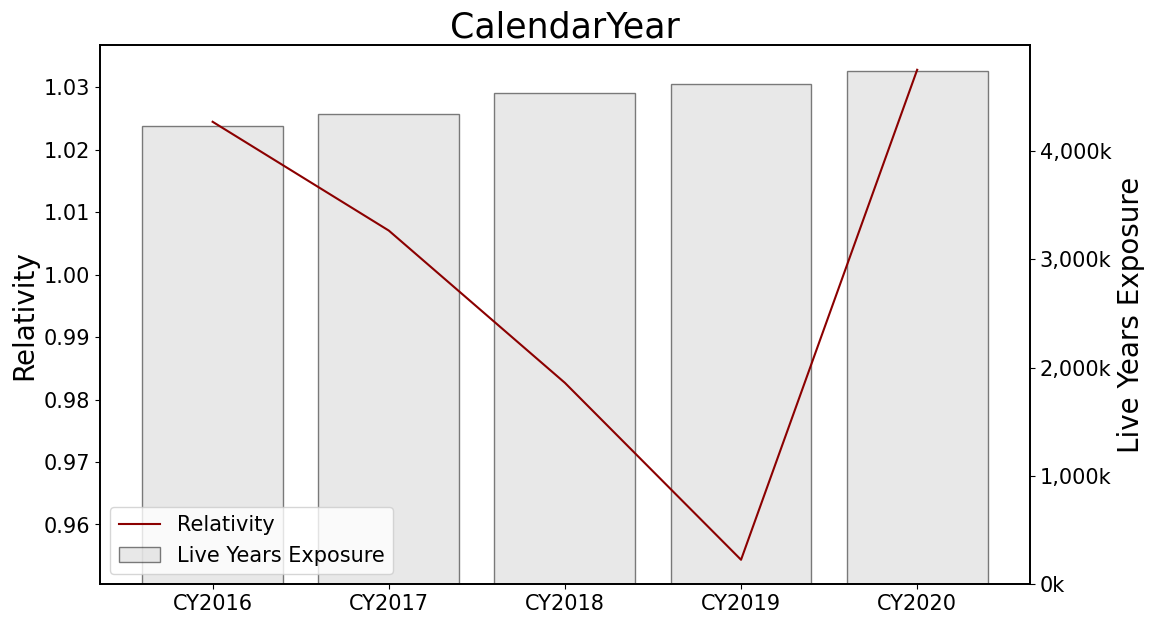

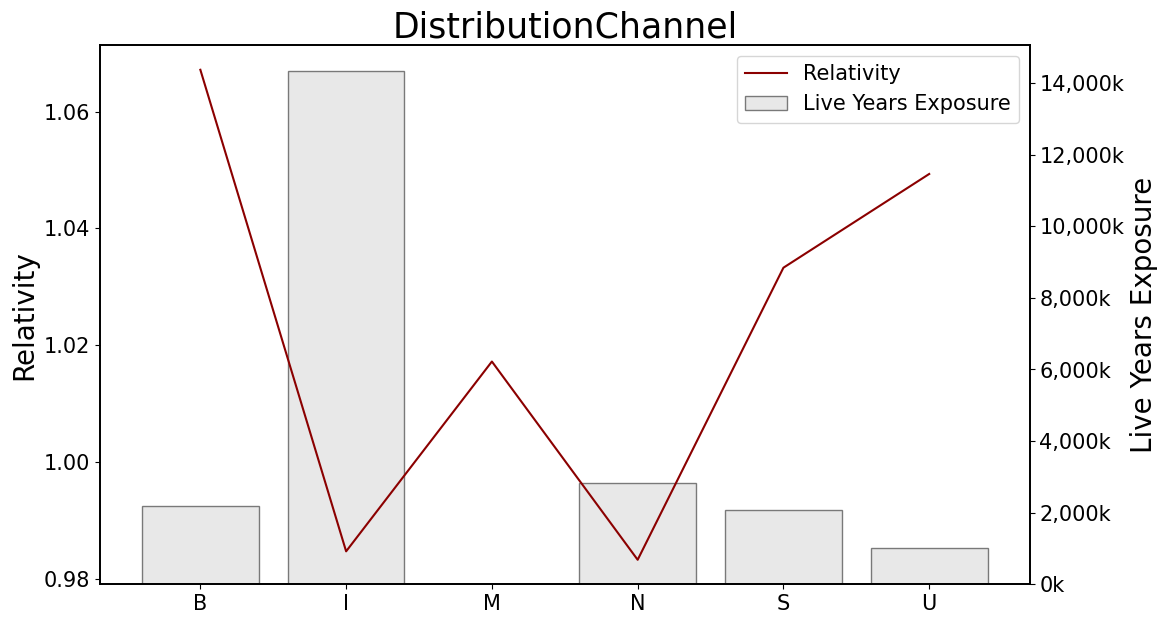

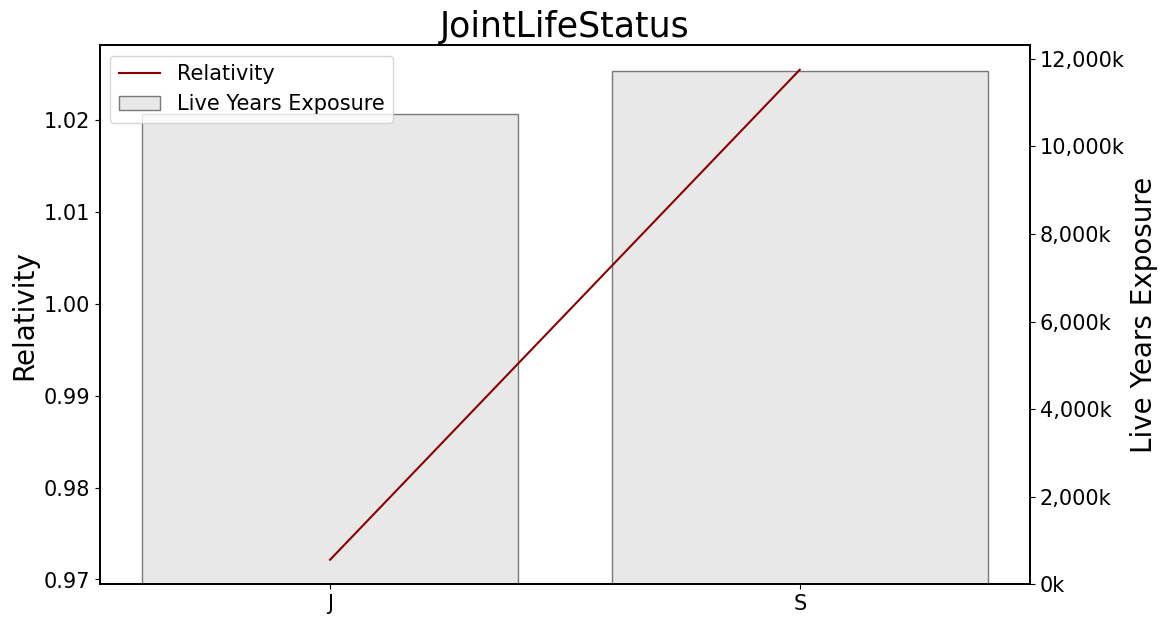

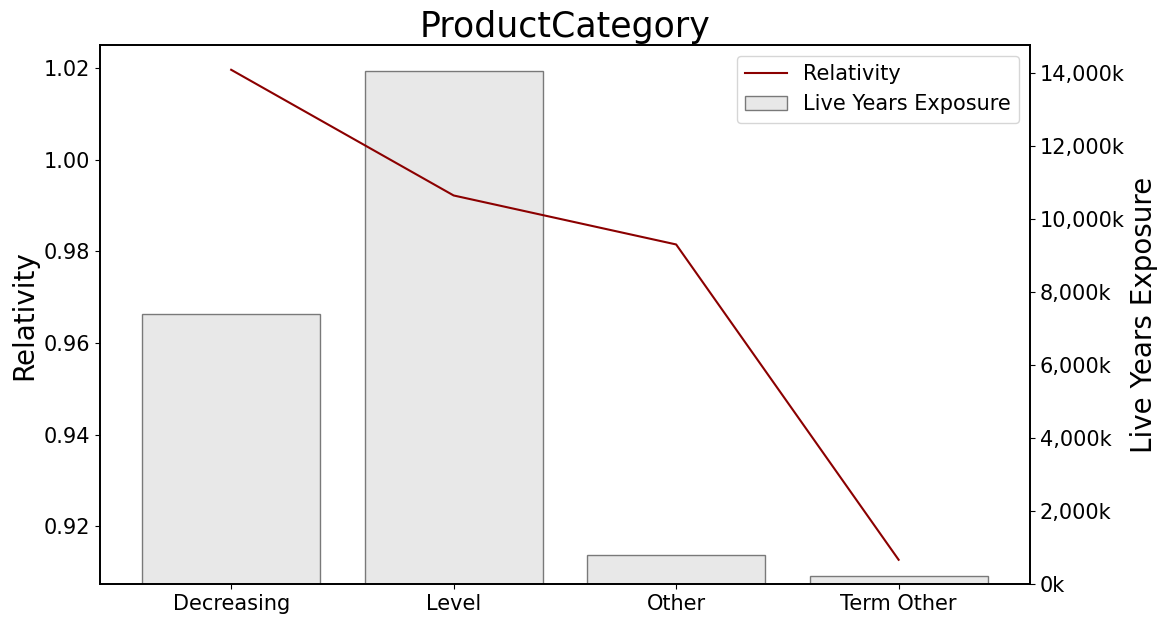

In [58]:
###################################################################
###################################################################

# Define the age variable
age_var = "Age"
rightylabel = "Live Years Exposure"
var_xtick_adj_list = []

###################################################################
###################################################################

for v in single_fact_df["feature"]:

    # Get the relativity table
    rel_table = (
        num_rel_dict[v] if v in num_rel_dict.keys() else cat_rel_dict[v + "_cat_level"]
    )
    rel_table = rel_table.set_index(v)
    # Start plotting
    fig, ax = plt.subplots(1, figsize=(12, 7))
    leftylabel = "Relativity (Log-Scale)" if v == age_var else "Relativity"

    sns.lineplot(data=rel_table["relativity"], ax=ax, color="darkred", label=leftylabel)

    ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)
    ax.set_xlabel("")
    ax.set_ylabel(leftylabel, fontsize=label_fontsize)
    ax.set_title(v.replace("_ordinal", ""), fontsize=title_fontsize)

    if v == age_var:
        ax.set_yscale("log")

        # Set specific tick locations
        ax.yaxis.set_major_locator(mtick.FixedLocator([1, 10]))

        # Format labels
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: "{:g}".format(y)))

        # Add minor ticks for gridlines
        ax.yaxis.set_minor_locator(
            LogLocator(base=10, subs=np.arange(2, 10), numticks=10)
        )
        ax.tick_params(axis="y", which="minor", length=5, width=1, direction="out")

    ax.grid(False)

    ax2 = ax.twinx()
    ax2.bar(
        rel_table.index,
        rel_table[weight],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=rightylabel,
    )
    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=ticker_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=ticker_fontsize,
        facecolor="white",
    )
    # Set secondary y-axis label
    ax2.set_ylabel(rightylabel, fontsize=label_fontsize)

    if v in var_xtick_adj_list:
        xticks = rel_table.index.values
        if len(xticks) > 15:
            step = len(xticks) // 10
            xticks = xticks[::step]
        ax.set_xticks(xticks)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)

### Actual vs Expected Analysis on Holdout

In [59]:
##################################################################
##################################################################

key_features = [x.replace("_ordinal", "") for x in single_fact_df["feature"]]

##################################################################
##################################################################

# Initialise an empty dict for holding the grouped by dataframes
risk_agg_dict = {}


for v in key_features:
    # Perform risk aggregations by individual features
    df_gb = utils.risk_agg(
        ypred_test_df.join(model_data[key_features]),
        v,
        weight,
        claim_count,
        cmi_death_count=cmi_base,
        gam_death_count=new_model_count,
    )
    # We're doing Actual vs Expected analysis
    df_gb["cmi_death_rate"] = df_gb["actual_death_rate"] / df_gb["cmi_death_rate"]
    df_gb["gam_death_rate"] = df_gb["actual_death_rate"] / df_gb["gam_death_rate"]

    risk_agg_dict[v] = df_gb

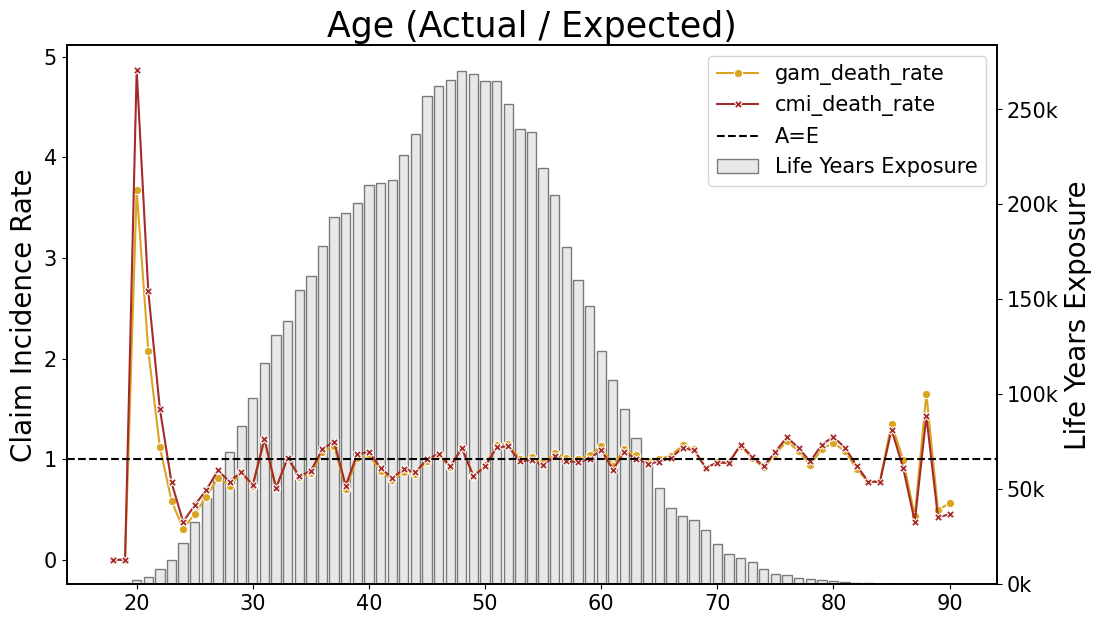

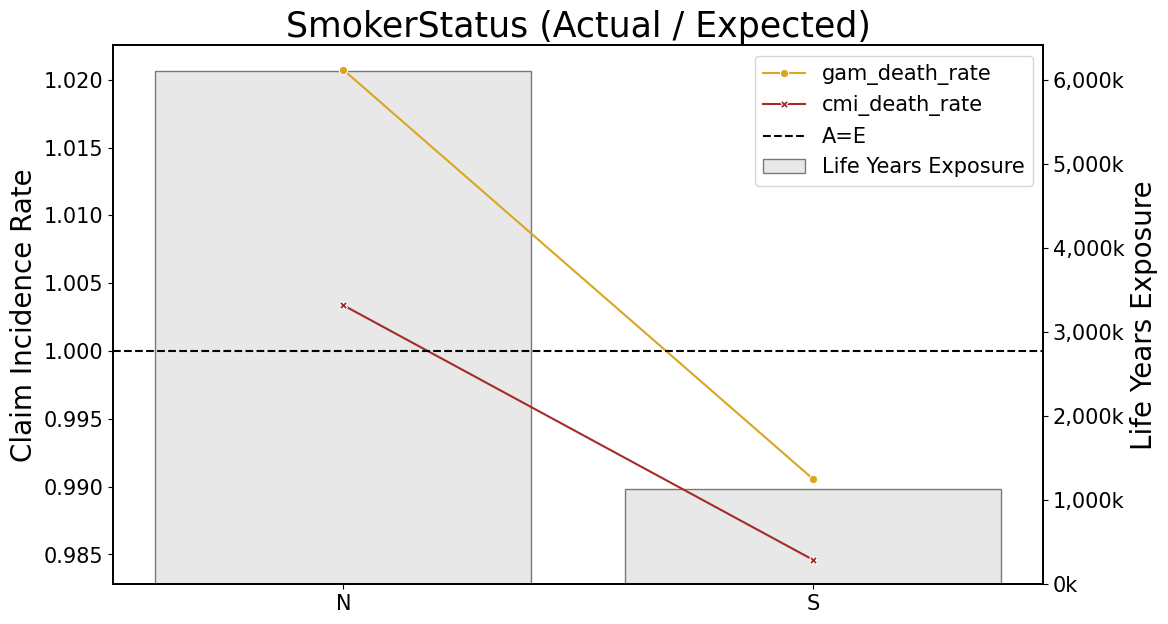

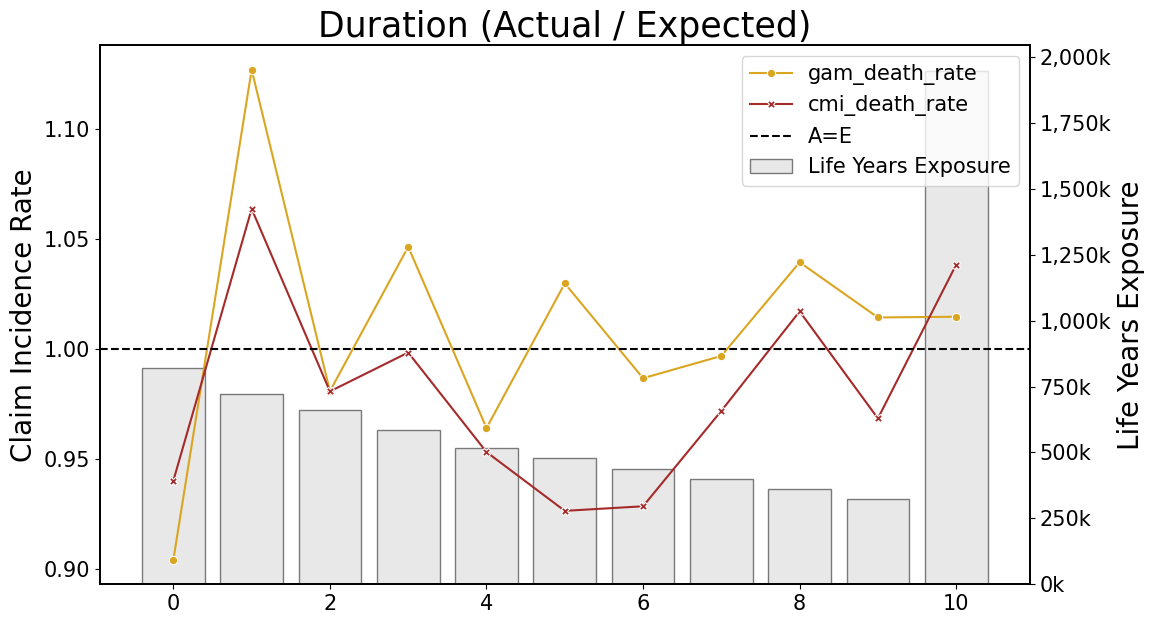

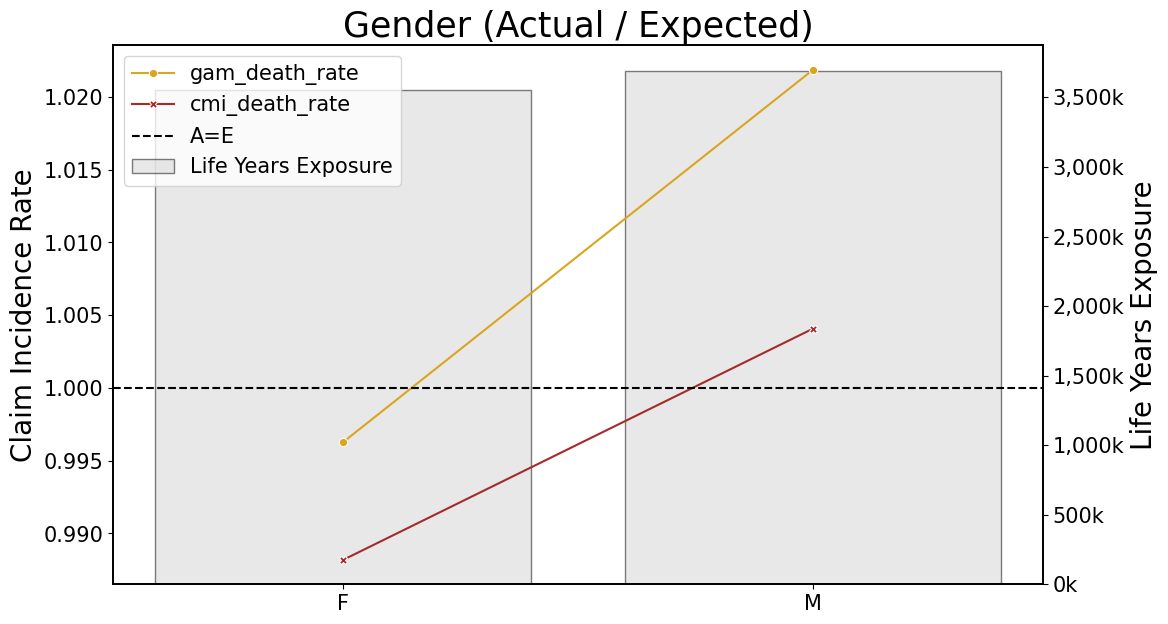

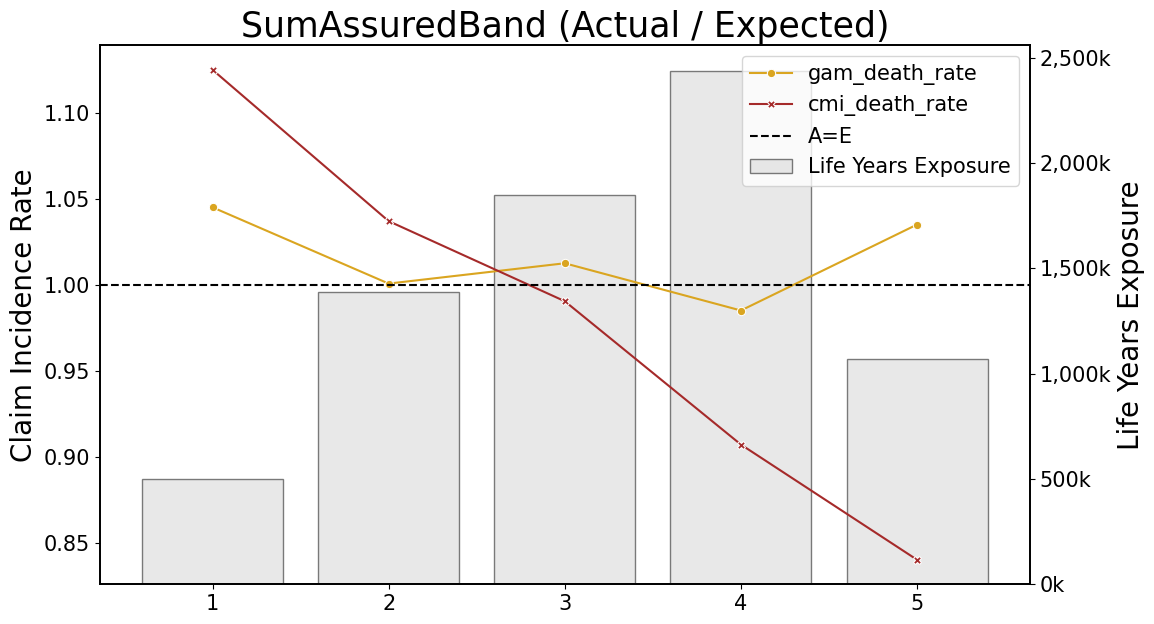

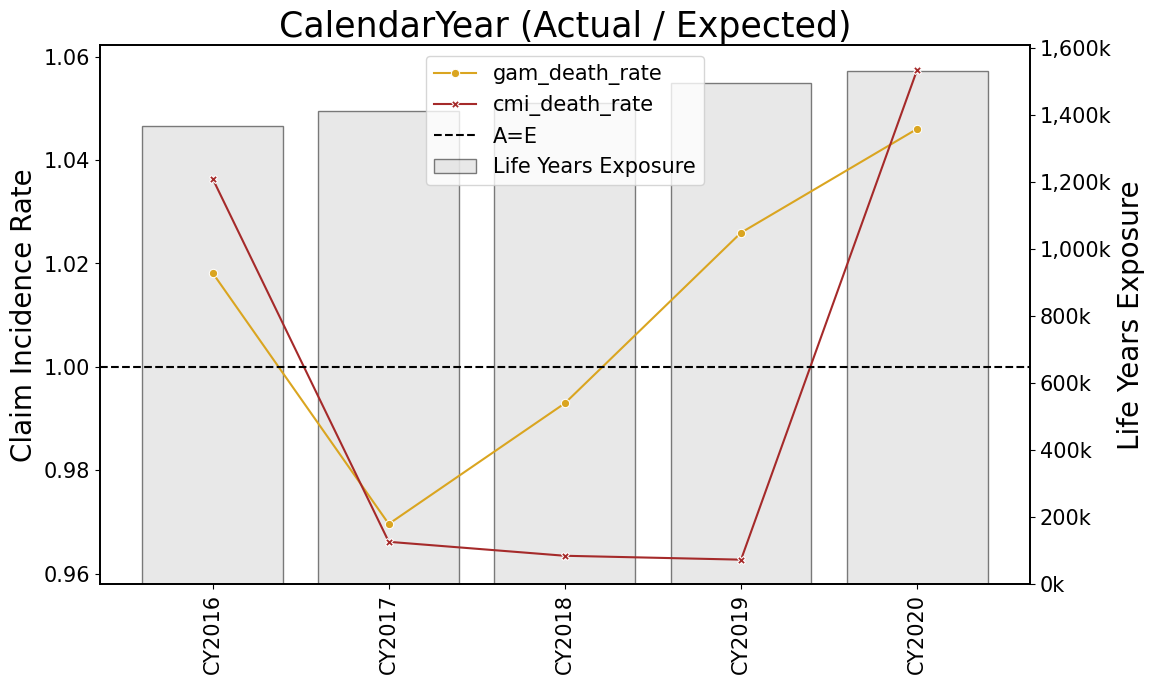

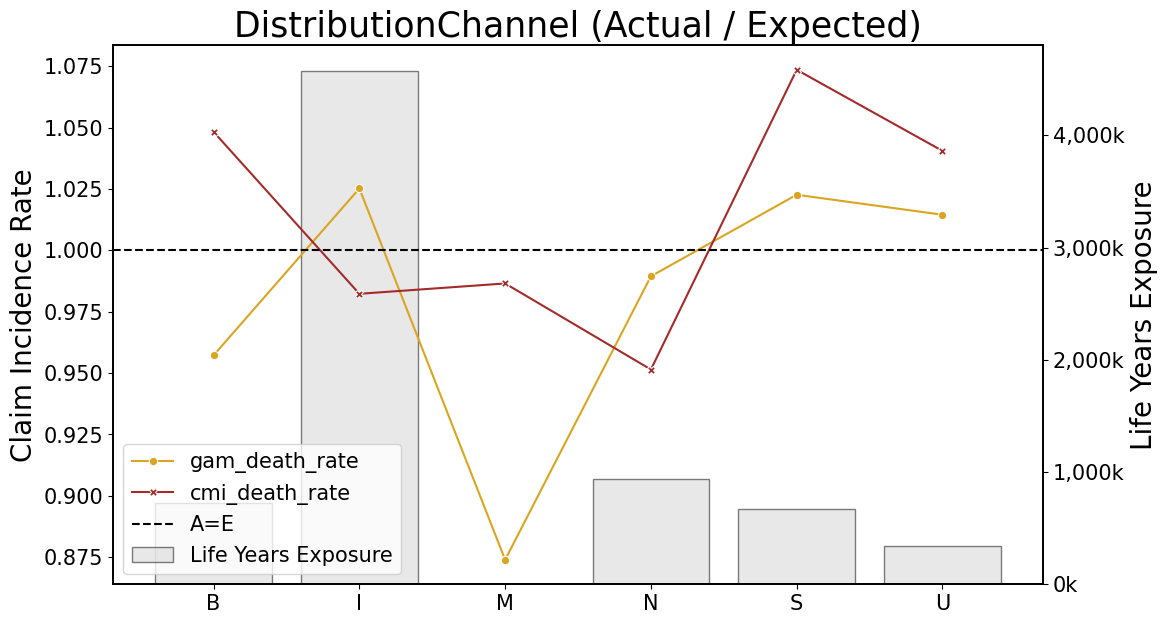

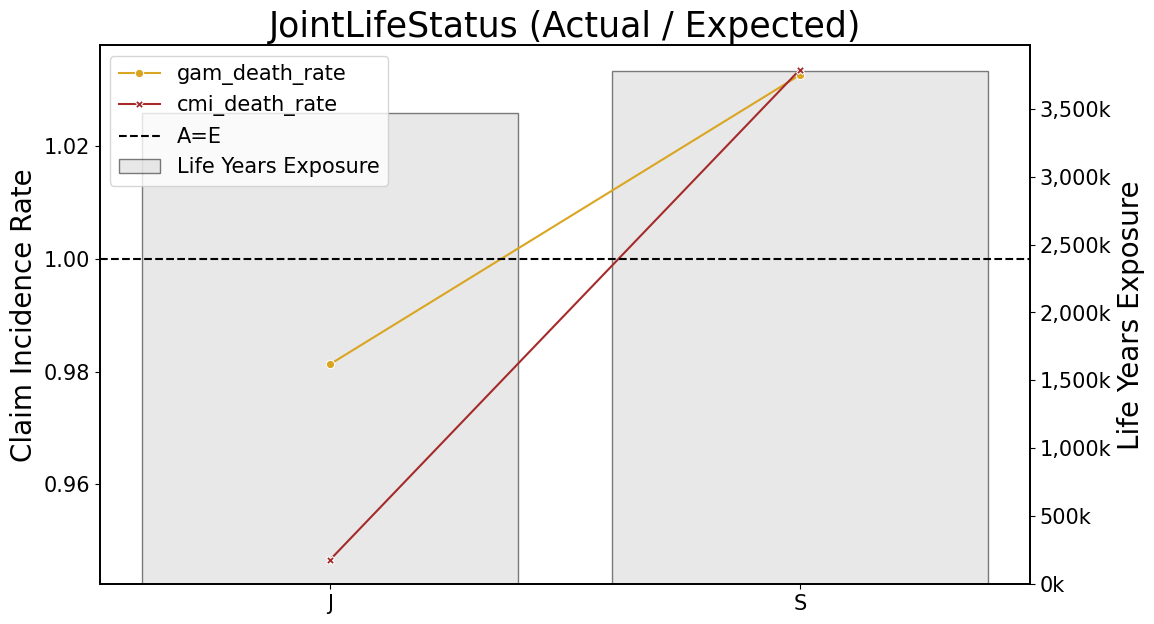

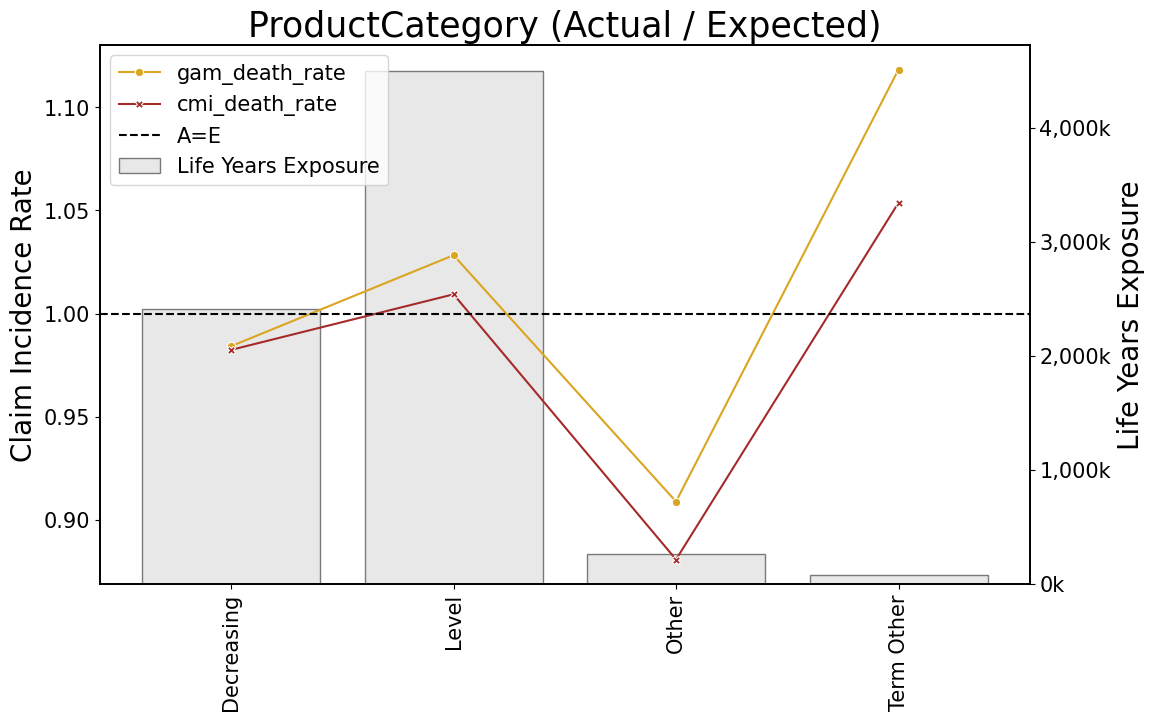

In [60]:
##############################################################################################
##############################################################################################

y1_label = "Claim Incidence Rate"
y2_label = "Life Years Exposure"

##############################################################################################
##############################################################################################

for var in key_features:

    fig, ax = plt.subplots(1, figsize=(12, 7))
    # Plot incidence rates
    sns.lineplot(
        data=risk_agg_dict[var].loc[
            :, ["gam_death_rate", "cmi_death_rate"]
        ],
        ax=ax,
        markers=True,
        dashes=False,
        palette=["#DAA520", "#A52A2A"],
    )
    ax.axhline(y=1, color="black", linestyle="--", label="A=E")

    # Set title and x and y axes labels and fontsize
    ax.set_ylabel(y1_label, fontsize=label_fontsize)
    ax.set_xlabel("")
    ax.set_title(var + " (Actual / Expected)", fontsize=title_fontsize)
    ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)

    # Fix the xticker labels if there are decimal places in xtickers when variable should be integers
    if not isinstance(risk_agg_dict[var].index[0], str):
        index_has_decimals = any(val % 1 != 0 for val in risk_agg_dict[var].index)
        ticks_have_decimals = any(tick % 1 != 0 for tick in ax.get_xticks())

        if not index_has_decimals and ticks_have_decimals:
            ax.set_xticks(risk_agg_dict[var].index)
            ax.set_xticklabels(risk_agg_dict[var].index)

    # Format x-axis tickers
    ax.tick_params(
        axis="x",
        rotation=(
            90
            if isinstance(risk_agg_dict[var].index[0], str)
            and len(risk_agg_dict[var].index[0]) > 4
            else 0
        ),
    )

    # Create secondary y-axis for exposures
    ax2 = ax.twinx()
    ax2.bar(
        risk_agg_dict[var].index,
        risk_agg_dict[var][weight],
        color="lightgray",
        alpha=0.5,
        ec="k",
        label=y2_label,
    )

    # Format secondary y-axis ticker
    ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
    ax2.tick_params(axis="y", which="major", labelsize=ticker_fontsize)

    # Combine legends
    lines, labels = ax.get_legend_handles_labels()
    bars, bar_labels = ax2.get_legend_handles_labels()
    ax.legend(
        lines + bars,
        labels + bar_labels,
        loc="best",
        fontsize=ticker_fontsize,
        facecolor="white",
    )

    # Set secondary y-axis label
    ax2.set_ylabel(y2_label, fontsize=label_fontsize)

    # Define order of layering
    ax.set_zorder(2)
    ax.patch.set_alpha(0)
    ax2.set_zorder(1)
    ax.grid(False)

### Distribution Comparison

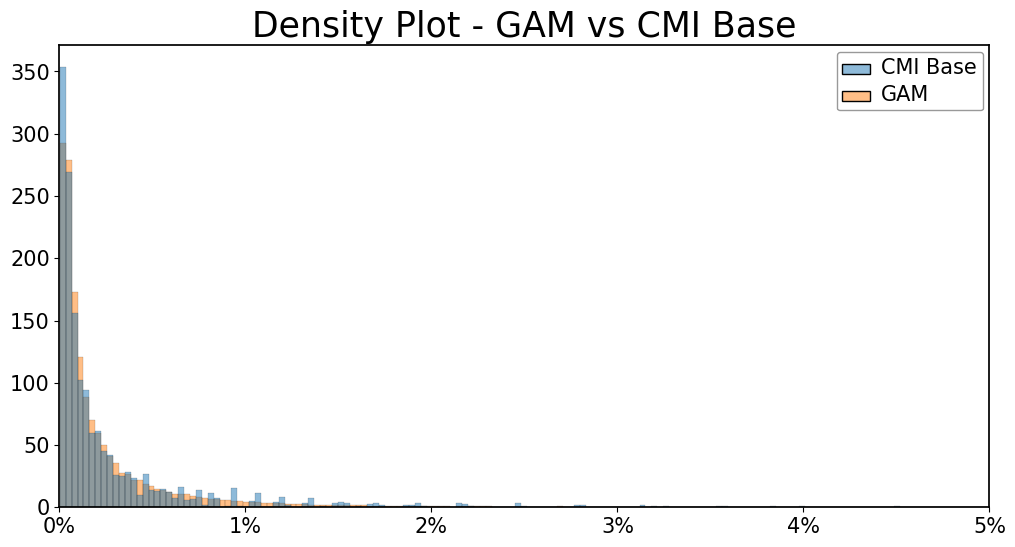

In [61]:
###########################################################################
###########################################################################

random_sample = 50000
random_seed = 999
color_list = ["tab:blue", "tab:orange"]
title = "Density Plot - GAM vs CMI Base"
x_axis_range = (0, 0.05)

###########################################################################
###########################################################################

dum = ypred_test_df[[cmi_freq, new_model_freq]].rename(
    columns={
        cmi_freq: "CMI Base",
        new_model_freq: "GAM",
    }
).sample(n=random_sample, random_state=random_seed)

plt.rcParams["figure.figsize"] = [12, 6]
fig, ax = plt.subplots(1)

sns.histplot(
    data=dum,
    kde=False,
    ax=ax,
    stat="density",
    palette=color_list,
    legend=True,
    alpha=0.5,
)

ax.set_xlim(x_axis_range[0], x_axis_range[1])
ax.set_title(title, fontsize=title_fontsize)
ax.tick_params(axis="both", which="major", labelsize=ticker_fontsize)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:.0%}"))
ax.grid(False)
ax.set_facecolor("white")

legend = ax.get_legend()
legend.set_frame_on(True)  
legend.get_frame().set_facecolor('white') 
legend.get_frame().set_edgecolor('grey')  
for text in legend.get_texts():
    text.set_fontsize(ticker_fontsize)